# Библиотека PyTorch

Обучаем нейронную сеть распознавать модели одежды из набора данных [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist).

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

Загружаем набор данных [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist).



In [2]:
# Загружаем набор данных для обучения
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Загружаем набор данных для тестирования
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.81MB/s]


In [3]:
training_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

Создаем ``DataLoader`` - загрузчик набора данных.


In [4]:
# Размер мини-выборки
batch_size = 64

# Создаем загрузчики данных
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Размерность X [N, C, H, W]: {X.shape}")
    print(f"Размерность y: {y.shape} {y.dtype}")
    break

Размерность X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Размерность y: torch.Size([64]) torch.int64


Названия классов

In [5]:
classes_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Плащ',
                 'Сандали', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

Просматриваем примеры изображений

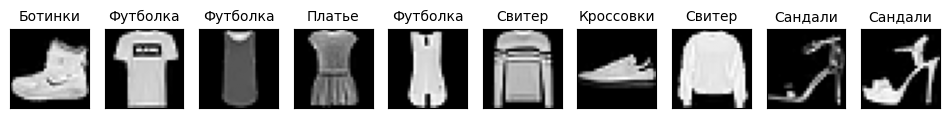

In [6]:
nsamples=10

imgs, labels = next(iter(train_dataloader))

fig=plt.figure(figsize=(12,5),facecolor='w')
for i in range(nsamples):
    ax = plt.subplot(1,nsamples, i+1)
    plt.imshow(imgs[i, 0, :, :], vmin=0, vmax=1.0, cmap=cm.gray)
    ax.set_title(classes_names[labels[i]], fontsize=10)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Создаем модель


Задаем устройство для работы модели


*   cpu - центральный процессор
*   cude - графический ускоритель NVIDIA
*   mps - графический ускоритель MAC



In [7]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [8]:
device

'cuda'

In [9]:
!nvidia-smi

Thu May  7 04:04:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Описываем класс для модели

In [11]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        # Слой преобразует двумерное изображение 28х28 в плоский вектор
        # размером 1х784
        self.flatten = nn.Flatten()
        # Контейней, содержащий слои, соединенные последовательно
        self.linear_relu_stack = nn.Sequential(
            # Полносвязный слой, 784 входа, 800 выходов
            nn.Linear(784, 800),
            # Полулинейная функция активации
            nn.ReLU(),
            # Полносвязный слой, 800 входов, 10 выходов (по количеству классов)
            nn.Linear(800, 10),
        )

    # Функция прямого прохода
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear_relu_stack(x)
        return x


Создаем модель на основе описанного класса

In [12]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=800, bias=True)
    (1): ReLU()
    (2): Linear(in_features=800, out_features=10, bias=True)
  )
)


--------------




## Обучаем модель

Задаем функцию ошибки - категориальная перекрестная энтропия



In [13]:
loss_fn = nn.CrossEntropyLoss()

Задаем оптимизатор

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Определяем функцию для обучения нейронной сети



In [15]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Включаем режим обучения
    model.train()
    # В цикле получаем все мини-выборки
    # X - изображение
    # y - номер класса
    for batch, (X, y) in enumerate(dataloader):
        # Передаем данные на устройство
        X, y = X.to(device), y.to(device)
        # Обнуляем значения градиента
        optimizer.zero_grad()

        # Расчитываем данные на выходе из нейронной сети
        pred = model(X)

        # Расчитываем значение ошибки
        loss = loss_fn(pred, y)

        # Обратное распространение ошиби
        loss.backward()

        # Выполняем шаг обучения (изменение весов)
        optimizer.step()

        # Печатаем прогресс каждые 100 мини-выборок
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Ошибка: {loss:>7f}  [{current:>5d}/{size:>5d}]")

Определяем функцию для проверки качества работы нейронной сети на тестовом наборе данных

In [16]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    # Включаем режим оценки качества модели
    model.eval()
    # Начальные значения
    test_loss, correct = 0, 0
    # Для оценки качества работы не нужно рассчитывать градиент
    with torch.no_grad():
        # В цикле проходим по мини-выборкам из тестового набора данных
        for X, y in dataloader:
            # Передаем данные на устройство
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Качество на тестовом наборе данных: \n Доля правильных ответов: {(100*correct):>0.1f}%, средняя ошибка: {test_loss:>8f} \n")

Обучаем модель в течение 10 эпох



In [17]:
epochs = 10
for t in range(epochs):
    print(f"Эпоха {t+1}\n-------------------------------")
    # Обучение модели
    train(train_dataloader, model, loss_fn, optimizer)
    # Оценка качества работы на тестовом объеме данных
    test(test_dataloader, model, loss_fn)
print("Обучение завершено!")

Эпоха 1
-------------------------------
Ошибка: 2.303080  [   64/60000]
Ошибка: 0.608388  [ 6464/60000]
Ошибка: 0.384593  [12864/60000]
Ошибка: 0.539001  [19264/60000]
Ошибка: 0.439670  [25664/60000]
Ошибка: 0.435302  [32064/60000]
Ошибка: 0.394587  [38464/60000]
Ошибка: 0.569916  [44864/60000]
Ошибка: 0.478186  [51264/60000]
Ошибка: 0.502890  [57664/60000]
Качество на тестовом наборе данных: 
 Доля правильных ответов: 84.9%, средняя ошибка: 0.422761 

Эпоха 2
-------------------------------
Ошибка: 0.265922  [   64/60000]
Ошибка: 0.337444  [ 6464/60000]
Ошибка: 0.286175  [12864/60000]
Ошибка: 0.402018  [19264/60000]
Ошибка: 0.397173  [25664/60000]
Ошибка: 0.383771  [32064/60000]
Ошибка: 0.352447  [38464/60000]
Ошибка: 0.518672  [44864/60000]
Ошибка: 0.376844  [51264/60000]
Ошибка: 0.452922  [57664/60000]
Качество на тестовом наборе данных: 
 Доля правильных ответов: 85.5%, средняя ошибка: 0.395604 

Эпоха 3
-------------------------------
Ошибка: 0.221717  [   64/60000]
Ошибка: 0.2922

## Сохранение обученной модели



Параметры модели

In [18]:
model.state_dict()

OrderedDict([('linear_relu_stack.0.weight',
              tensor([[ 1.8587e-01, -5.3892e-02,  3.5400e-02,  ...,  1.3794e-01,
                        2.8179e-01,  1.9395e-01],
                      [-4.0102e-02, -4.7812e-03, -1.9485e-04,  ..., -8.0727e-02,
                       -3.0326e-02, -5.3217e-05],
                      [ 9.4070e-02,  6.6387e-02,  4.9684e-02,  ..., -5.0131e-02,
                       -8.7173e-03,  1.1850e-01],
                      ...,
                      [ 5.7040e-03, -2.7605e-01, -1.4440e-01,  ..., -1.3327e-01,
                       -1.3016e-01,  2.1347e-01],
                      [ 1.8079e-03,  2.2840e-02,  1.8611e-02,  ..., -5.2365e-02,
                        8.1610e-04,  4.2248e-02],
                      [-1.6099e-01,  5.4384e-02,  8.3893e-02,  ..., -6.4162e-03,
                       -1.9588e-01, -2.6031e-02]], device='cuda:0')),
             ('linear_relu_stack.0.bias',
              tensor([ 5.2279e-02,  8.4115e-02,  4.0773e-01,  1.5336e-01, -1.3596

In [19]:
torch.save(model.state_dict(), "model.pth")

## Загрузка модели



In [20]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

## Распознавание изображений из тестового набора данных



In [21]:
model.eval()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=800, bias=True)
    (1): ReLU()
    (2): Linear(in_features=800, out_features=10, bias=True)
  )
)

In [22]:
x, y = test_data[1][0], test_data[1][1]

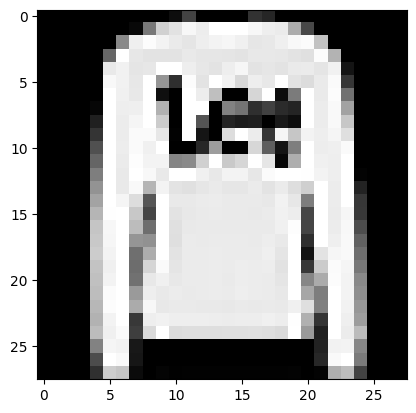

In [23]:
plt.imshow(x[0, :, :], vmin=0, vmax=1.0, cmap=cm.gray)

Запускаем распознавание

In [24]:
with torch.no_grad():
    x = x.to(device)
    pred = model(x)

Результаты распознавания

In [25]:
pred

tensor([[ -3.8237, -17.8895,   4.3959, -12.0839,  -0.3873, -15.8246,  -1.8190,
         -14.8083, -15.0565, -14.3466]], device='cuda:0')

Номер класса

In [26]:
pred[0].argmax(0)

tensor(2, device='cuda:0')

Название класса

In [27]:
classes_names[pred[0].argmax(0)]

'Свитер'

Правильный ответ

In [28]:
y

2

In [29]:
classes_names[y]

'Свитер'